In [1]:
import pandas as pd
import numpy as np
import torch
from opensoundscape.ml.shallow_classifier import MLPClassifier

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[1], 'GPU')
        tf.config.set_logical_device_configuration(
            gpus[1],
            [tf.config.LogicalDeviceConfiguration(memory_limit=5000)]
        )
    except RuntimeError as e:
        print(e)

import bioacoustics_model_zoo as bmz

perch = bmz.Perch2()

2026-04-13 12:33:13.018377: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations 

In [3]:
# load your already-made shallow dfs
train_clips = pd.read_pickle(
    "/media/auk/projects/gak76/vira_beg_outputs/training_data/splits/shallow_train_df_gk_40926.pkl"
)
test_clips = pd.read_pickle(
    "/media/auk/projects/gak76/vira_beg_outputs/training_data/splits/shallow_test_df_gk_40926.pkl"
)

TARGET = "virail"

print(train_clips.head())
print(test_clips.head())


                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.481836   1.481836       1
                                                   1.684151   2.684151       1
                                                   2.723180   3.723180       1
                                                   4.061076   5.061076       1
                                                   4.290522   5.290522       1
                                                                        virail
file                                               start_time end_time        
/home/brg226/projects/vira_beg/training_data/an... 0.378303   1.378303       1
                                                   0.876813   1.876813       1
                                                   2.164027   3.164027       1
                                                   3

In [4]:
# make sure target is float for perch.train()
train_clips[TARGET] = train_clips[TARGET].astype(float)
test_clips[TARGET] = test_clips[TARGET].astype(float)

print(train_clips[TARGET].value_counts())
print(test_clips[TARGET].value_counts())

virail
0.0    2928
1.0     244
Name: count, dtype: int64
virail
0.0    348
1.0     29
Name: count, dtype: int64


In [5]:

# initialize shallow classifier head
perch.initialize_custom_classifier(
    hidden_layer_sizes=(),
    new_classes=train_clips.columns.tolist()
)

In [6]:
# train shallow classifier
perch.train(
    train_clips,
    None,
    n_augmentation_variants=0,
    embedding_batch_size=32,
    embedding_num_workers=4
)

Embedding the training samples without augmentation


  0%|          | 0/100 [00:00<?, ?it/s]

/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/audio.py:1757: UserWarning: Audio object is shorter than requested duration: 0.706625 sec instead of 1.0 sec
  warnings.warn(error_msg)
/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/audio.py:1757: UserWarning: Audio object is shorter than requested duration: 0.39740625 sec instead of 1.0 sec
  warnings.warn(error_msg)
/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/audio.py:1757: UserWarning: Audio object is shorter than requested duration: 0.7845625 sec instead of 1.0 sec
  warnings.warn(error_msg)
2026-04-13 12:33:50.543446: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f767006de30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-13 12:33:50.543981: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
202

Fitting the classifier


/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/shallow_classifier.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_features = torch.tensor(train_features, dtype=torch.float32, device=device)
/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/ml/shallow_classifier.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)


Training complete


2026-04-13 12:34:49.237989: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-13 12:34:49.326434: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[4,1392,16,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,1392,16,4]{3,2,1,0}, f32[1392,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=1392, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-13 12:34:49.365065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-opt

In [7]:
# save classifier
perch.save("/media/auk/projects/gak76/vira_beg_outputs/models/virail_perch_041326_try3.pth")

In [9]:
import torch

torch.cuda.empty_cache()

perch.device = "cpu"
perch.network = perch.network.cpu()

preds = perch.predict(
    test_clips,
    batch_size=1,
    num_workers=0
)

  0%|          | 0/377 [00:00<?, ?it/s]

/home/sml161/miniconda3/envs/perch2/lib/python3.11/site-packages/opensoundscape/audio.py:1757: UserWarning: Audio object is shorter than requested duration: 0.89703125 sec instead of 1.0 sec
  warnings.warn(error_msg)


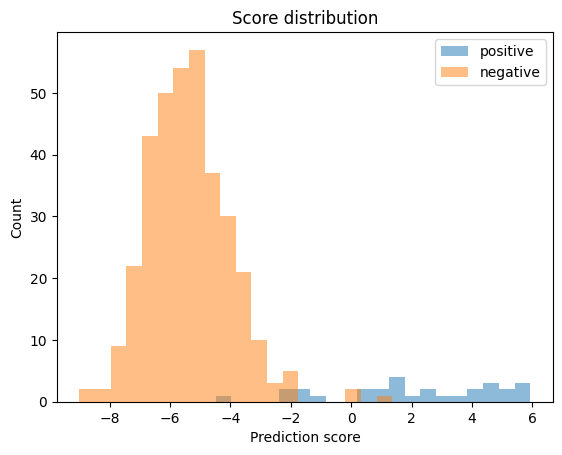

In [11]:
import matplotlib.pyplot as plt

TARGET = "virail"

scores = preds[TARGET]
labels = test_clips.loc[preds.index, TARGET]

plt.hist(scores[labels == 1], bins=20, alpha=0.5, label="positive")
plt.hist(scores[labels == 0], bins=20, alpha=0.5, label="negative")

plt.legend()
plt.title("Score distribution")
plt.xlabel("Prediction score")
plt.ylabel("Count")
plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from opensoundscape import Audio, Spectrogram

TARGET = "virail"

# --- align labels and scores ---
scores = preds[TARGET].copy()
labels = test_clips.loc[preds.index, TARGET].astype(int).copy()

results = pd.DataFrame({
    "score": scores,
    "true_label": labels
}, index=preds.index)

# choose a threshold
threshold = .99

results["pred_label"] = (results["score"] >= threshold).astype(int)

# confusion-group masks
tp = results[(results["true_label"] == 1) & (results["pred_label"] == 1)]
tn = results[(results["true_label"] == 0) & (results["pred_label"] == 0)]
fp = results[(results["true_label"] == 0) & (results["pred_label"] == 1)]
fn = results[(results["true_label"] == 1) & (results["pred_label"] == 0)]

print("Threshold:", threshold)
print("TP:", len(tp))
print("TN:", len(tn))
print("FP:", len(fp))
print("FN:", len(fn))

Threshold: 0.99
TP: 21
TN: 347
FP: 1
FN: 8


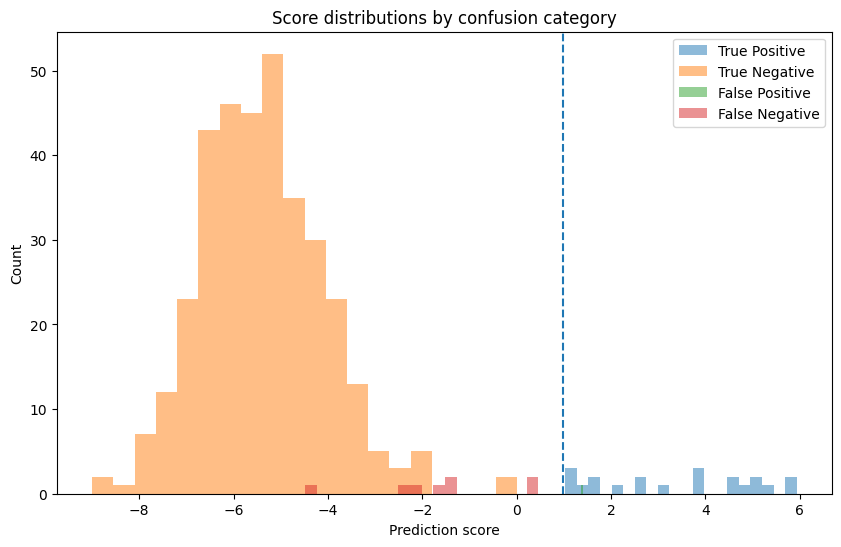

In [16]:
plt.figure(figsize=(10, 6))

bins = 20
plt.hist(tp["score"], bins=bins, alpha=0.5, label="True Positive")
plt.hist(tn["score"], bins=bins, alpha=0.5, label="True Negative")
plt.hist(fp["score"], bins=bins, alpha=0.5, label="False Positive")
plt.hist(fn["score"], bins=bins, alpha=0.5, label="False Negative")

plt.axvline(threshold, linestyle="--")
plt.xlabel("Prediction score")
plt.ylabel("Count")
plt.title("Score distributions by confusion category")
plt.legend()
plt.show()

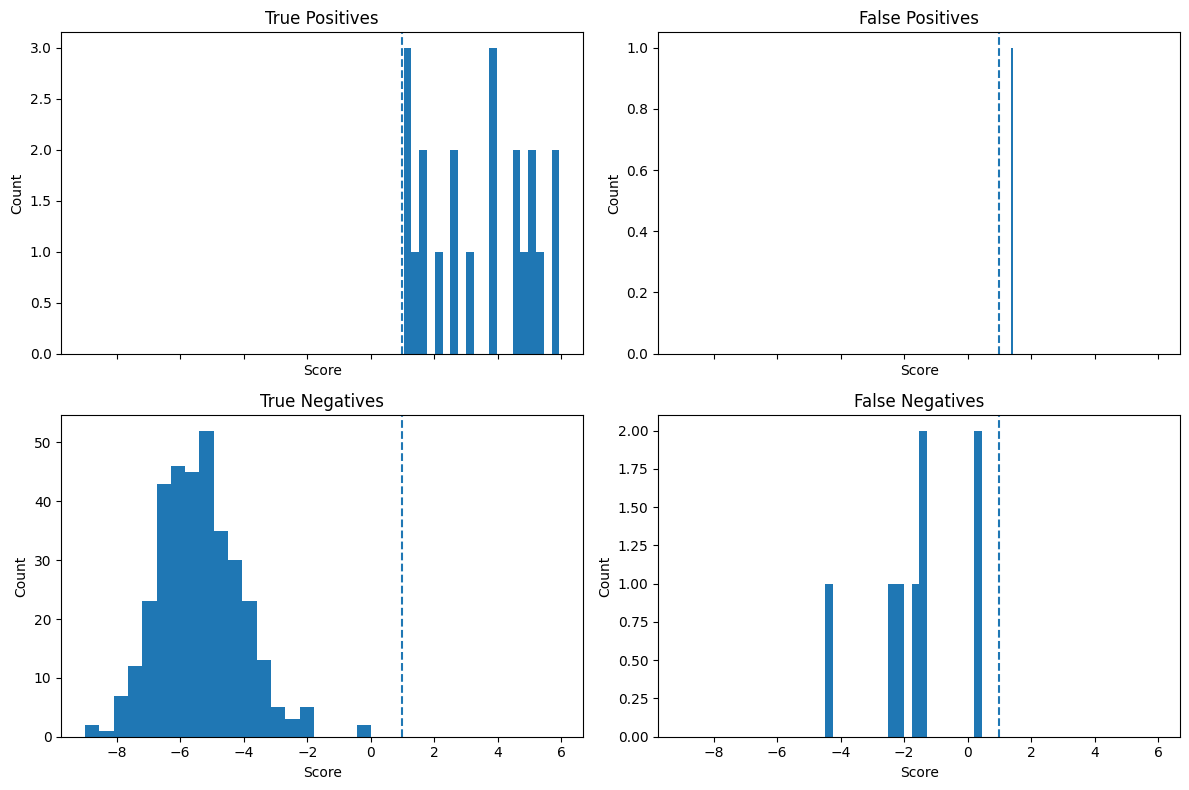

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].hist(tp["score"], bins=20)
axes[0, 0].set_title("True Positives")

axes[0, 1].hist(fp["score"], bins=20)
axes[0, 1].set_title("False Positives")

axes[1, 0].hist(tn["score"], bins=20)
axes[1, 0].set_title("True Negatives")

axes[1, 1].hist(fn["score"], bins=20)
axes[1, 1].set_title("False Negatives")

for ax in axes.ravel():
    ax.axvline(threshold, linestyle="--")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [18]:
top_n = 6
top_fp = fp.sort_values("score", ascending=False).head(top_n)
top_fp

,,,score,true_label,pred_label
file,start_time,end_time,,,
/media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0008.tar.gz/XC235014.ogg,0.016,1.016,1.359791,0,1


In [22]:
top_fp = fp.sort_values("score", ascending=False).head(5)

for idx, row in top_fp.iterrows():
    file_path, start_time, end_time = idx
    print(f"\nscore={row['score']:.3f} | {file_path} | {start_time:.3f}-{end_time:.3f}")
    audio = Audio.from_file(file_path)
    clip = audio.trim(start_time=start_time, end_time=end_time)
    display(clip.show_widget())


score=1.360 | /media/kiwi/datasets/annotated/xeno_canto_snapshot/data_cache/hub/datasets--DBD-research-group--BirdSet/snapshots/ee31c6ba7dd653e57bf327bdd0c1bde6b0334bba/XCL/extracted/XCL_shard_0008.tar.gz/XC235014.ogg | 0.016-1.016


None